# Pointmass Demo

The simplest lens model in CosmoSim is the pointmass, where all
the mass is compressed in a singular point.
This model is implemented many times.
Currently, there is a `PointMass` lens which can be used with the
standard models, `RouletteModel` and `RaytraceModel`.
The original implementations `PointMassRoulette` and
`PointMassExact` should be equivalent, but used a closed form
specific to the point mass lens, and thus cannot be modularised.

## Preparation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import toml

import CosmoSim as cs
from CosmoSim import CosmoSim, Parameters
from CosmoSim.datagen import SimImage
import CosmoSim.Image as csimg

print( "CosmoSim version:", cs.__version__ )

CosmoSim version: 3.1.2


## The exact models

We can define the configuration as a dict using the nested (TOML) structure.

In [2]:
cfg = { 'simulator' : { "model" : "Raytrace", "cropsize" : 256 }
      , 'lens': { 
            'mode' : "PM",
            'einsteinR': 46,
            'ellipseratio': 0.34,
            'orientation': 107,
            'chi': 50}
      , 'source': {
            'mode': 'Spherical',
            'sigma': 7,
            'position': 'cartesian'}
      , 'position': {'x': 35, 'y': 15}
      }

In [3]:
param = Parameters( cfg )
imsim01 = SimImage( param, verbose=0 )
im01 = imsim01.getImage()

To run the same simulation with the legacy, exact model, we simply change the
simulator setting and rerun.

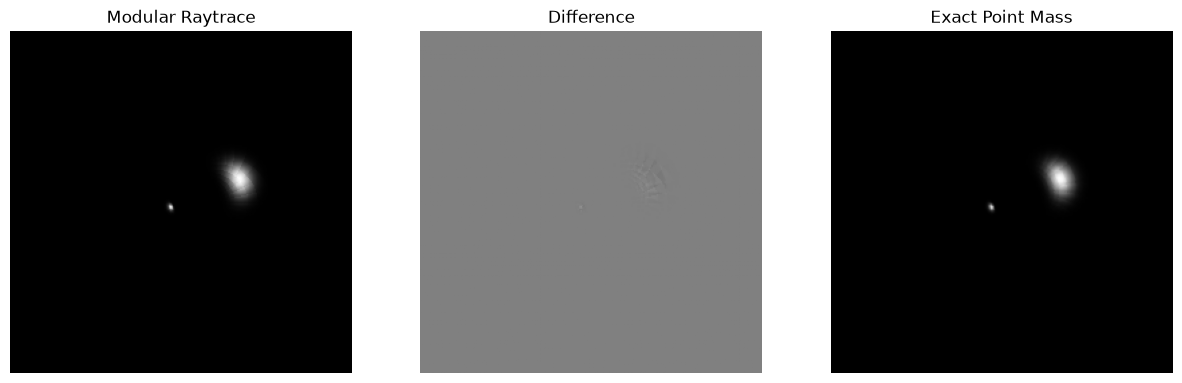

In [4]:
param["simulator"]["model"] = "Point Mass (exact)" 
imsim02 = SimImage( param, verbose=0 )
im02 = imsim02.getImage()
csimg.imageCompare( im01, im02, "Modular Raytrace", 'Exact Point Mass')

There is a visual discrepancy, but it is hard to tell if this is significant.
Quite likely, it is due to numeric errors.

::: {note} Implementation
The original closed form was implemented with the source located on the $x$-axis,
and then the distorted image was rotated to according to the proper location of
the source.  Numeric error may have been introduced by this extra rotation step.
:::

## The original roulette

The roulette formalism is also implemented in a closed form.

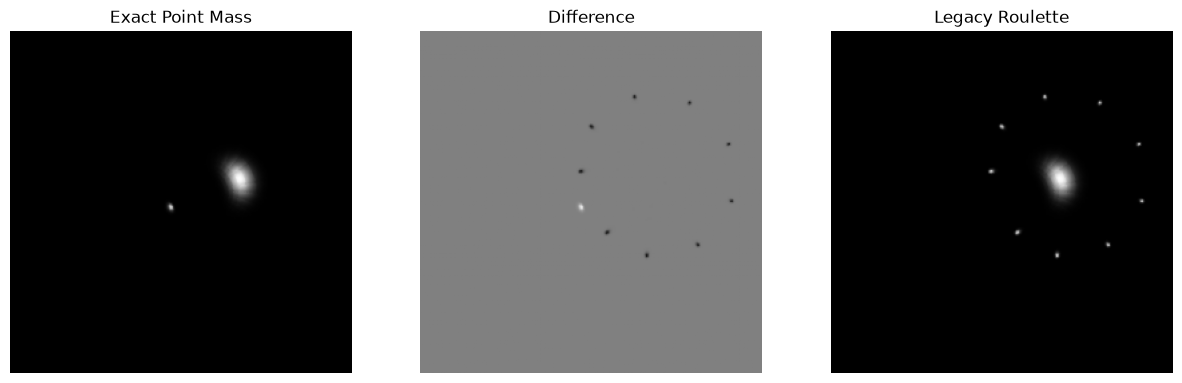

In [5]:
param["simulator"]["model"] = "Point Mass (roulettes)"
param["simulator"]["nterms"] = 8
imsim03 = SimImage( param, verbose=0 )
im03 = imsim03.getImage()
csimg.imageCompare( im02, im03, "Exact Point Mass", 'Legacy Roulette')

This looks perfect inside the convergence ring, as it should.

## Modular roulette

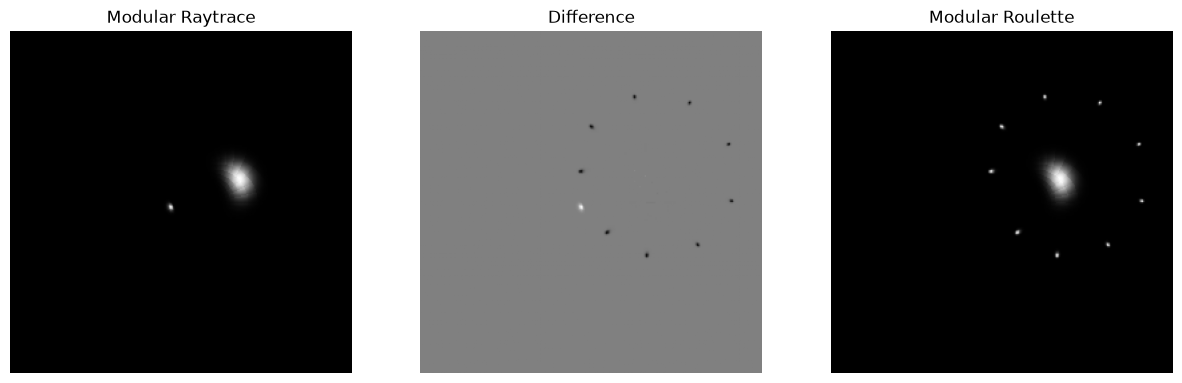

In [6]:
param["simulator"]["model"] = "Roulette"
imsim04 = SimImage( param, verbose=0 )
im04 = imsim04.getImage()
csimg.imageCompare( im01, im04, "Modular Raytrace", 'Modular Roulette')

Again, the roulette simulation is perfect within the convergence ring.

If we compare the closed form and modular implementations, we find
a discrepancy similar to what we had for the exact model and raytrace.

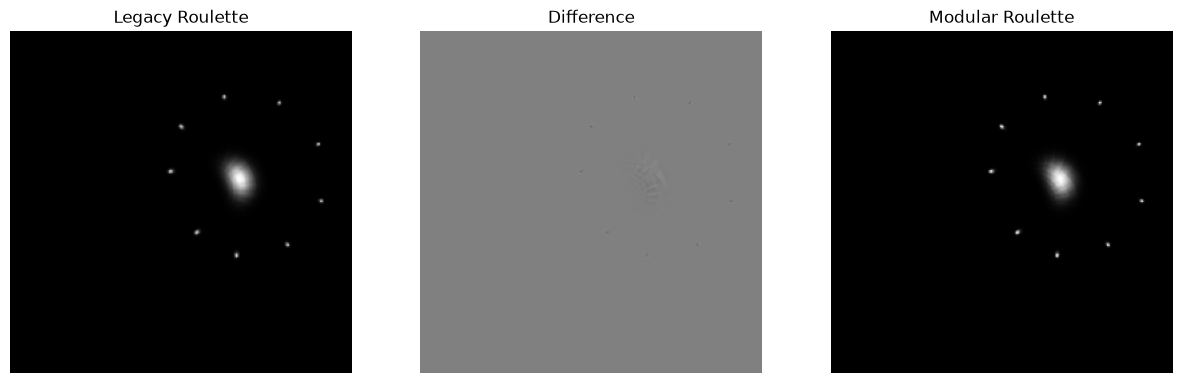

In [7]:
csimg.imageCompare( im03, im04, "Legacy Roulette", 'Modular Roulette')

## Sampling

The modular implementation allows for sampling and solution by numeric
differentiation.
Let us first test raytrace simulation and compare sampled and analytic
solutions.

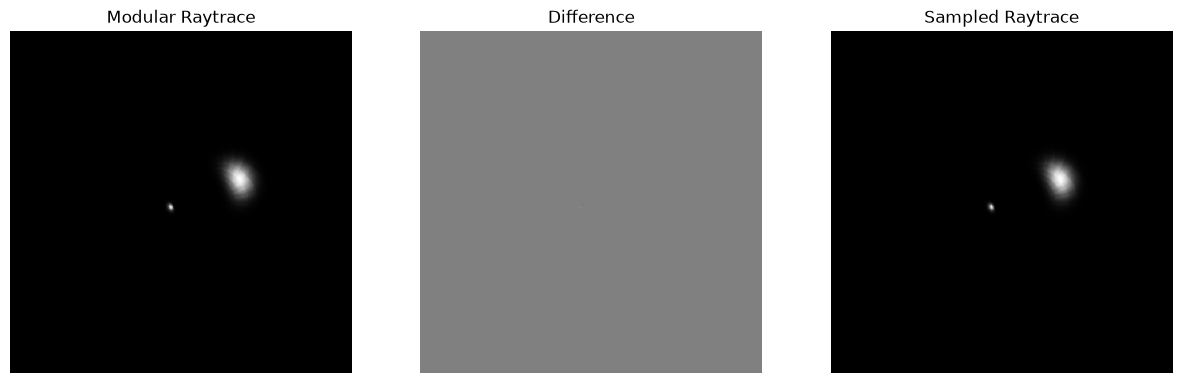

In [8]:
param["simulator"]["model"] = "Raytrace"
raytrace = SimImage( param, verbose=0 ).getImage()
param["simulator"]["sampled"] = True
raytraceS = SimImage( param, verbose=0 ).getImage()
csimg.imageCompare( raytrace, raytraceS, "Modular Raytrace", 'Sampled Raytrace')

This looks perfect.

Then we can do the same with roulette.

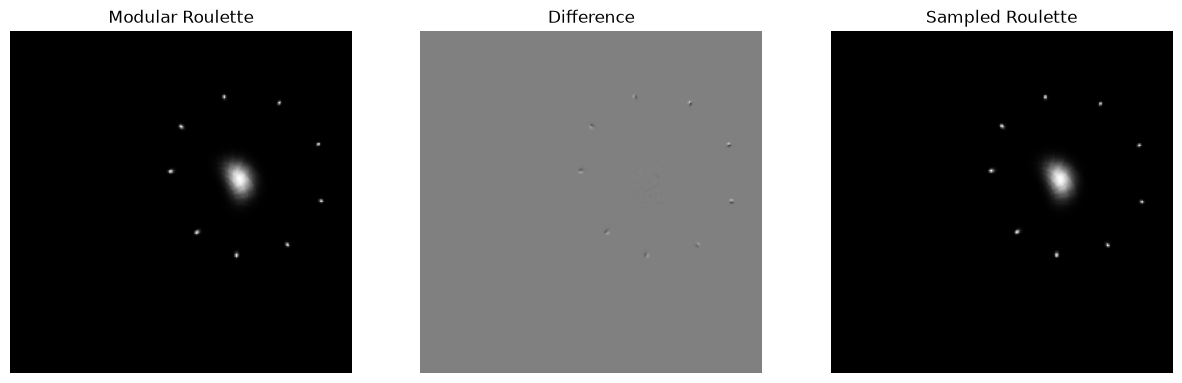

In [9]:
param["simulator"]["model"] = "Roulette"
rouletteS = SimImage( param, verbose=0 ).getImage()
csimg.imageCompare( im04, rouletteS, "Modular Roulette", 'Sampled Roulette')

This gives a minor discrepancy in the spurious images, which may well be
due to numeric approximation.

It is also useful to compare to the closed form implementations too.

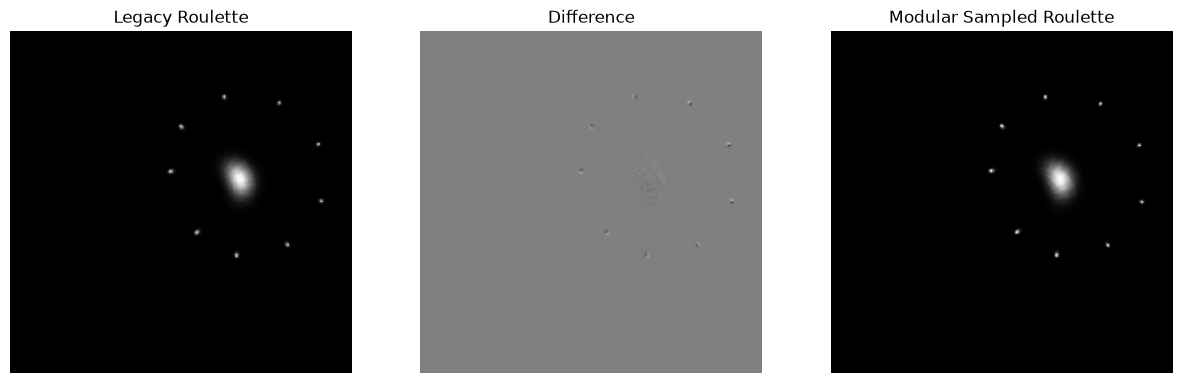

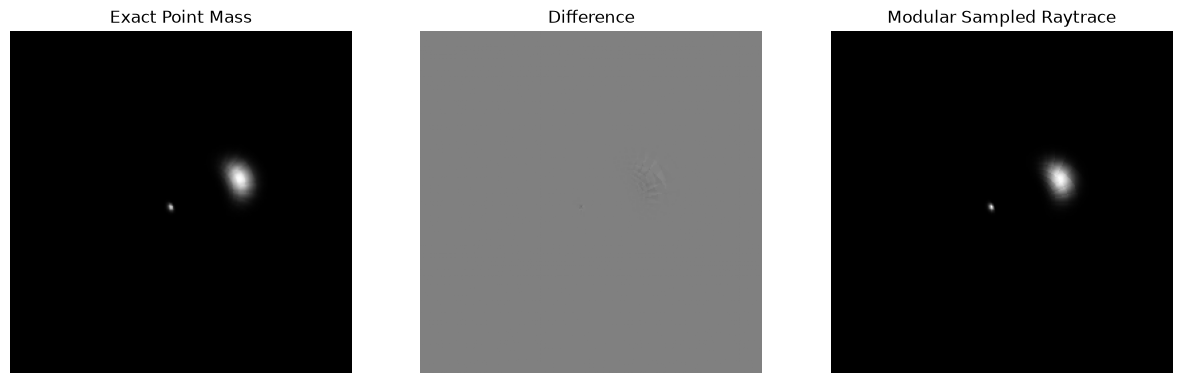

In [10]:
csimg.imageCompare( im03, rouletteS, "Legacy Roulette", 'Modular Sampled Roulette')
csimg.imageCompare( im02, raytraceS, "Exact Point Mass", 'Modular Sampled Raytrace')

Here we have discrepancy similar to what we first saw between the closed form and
modular implementations.

## Rotation

The discrepancy that we have found may be due to rotation in the closed form
implementation.  We can test this by using a source on the $x$-axis.

In [11]:
cfg = { 'simulator' : { "model" : "Raytrace", "cropsize" : 256 }
      , 'lens': { 
            'mode' : "PM",
            'einsteinR': 46,
            'ellipseratio': 0.34,
            'orientation': 107,
            'chi': 50}
      , 'source': {
            'mode': 'Spherical',
            'sigma': 7,
            'position': 'cartesian'}
      , 'position': {'x': 40, 'y': 0}
      }

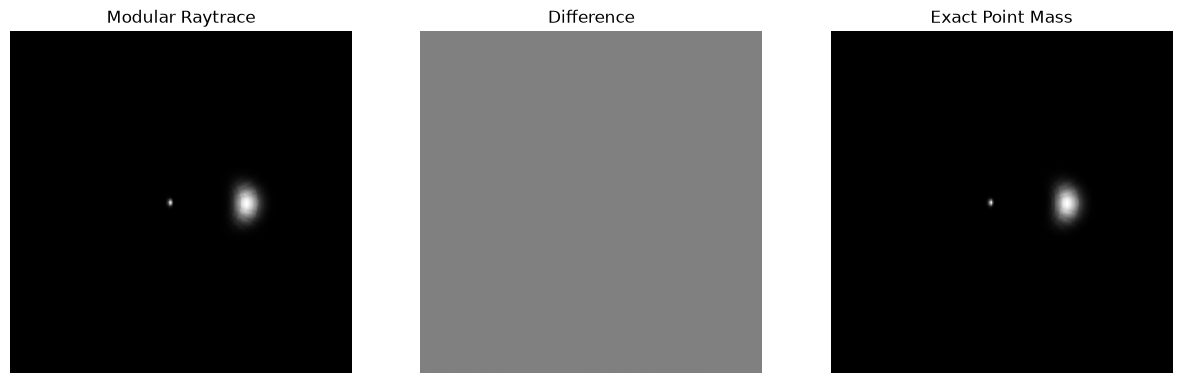

In [12]:
param = Parameters( cfg )
rotM = SimImage( param, verbose=0 ).getImage()

param["simulator"]["model"] = "Point Mass (exact)" 
rotX = SimImage( param, verbose=0 ).getImage()
csimg.imageCompare( rotM, rotX, "Modular Raytrace", 'Exact Point Mass')

This is a perfect match as far as visiual perception goes.
We can repeat the experiment with Roulettes.

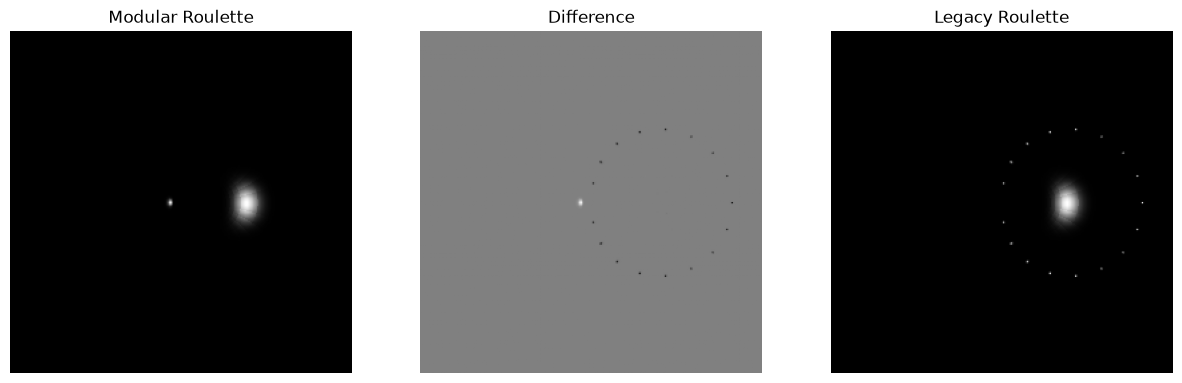

In [13]:
param["simulator"]["model"] = "Roulette" 
param = Parameters( cfg )
rotMR = SimImage( param, verbose=0 ).getImage()

param["simulator"]["model"] = "Point Mass (roulettes)" 
rotR = SimImage( param, verbose=0 ).getImage()
csimg.imageCompare( rotMR, rotR, "Modular Roulette", 'Legacy Roulette')

Again we have a perfect match.

## Conclusion

We note that there is a discrepancy between the modular and closed form implementations,
which may be due to the rotation of the image employed in the closed form implementations.

We also had a discrepancy in between the sampled and unsampled modular roulette impllementations,
but this only affects the spurious images.